In [37]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from chembl_structure_pipeline import standardizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from rdkit.Chem import rdFingerprintGenerator
import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [15]:
df_receptor = pd.read_csv('data/receptor_std.csv')
df_zinc = pd.read_csv('data/zinc_std.csv')

In [17]:
df_receptor['mol'] = df_receptor['std_smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_zinc['mol'] = df_zinc['std_smiles'].apply(lambda x: Chem.MolFromSmiles(x))

# Morgan fingerprints

In [22]:
mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
receptor_fps = [mfp_gen.GetFingerprintAsNumPy(m) for m in df_receptor['mol']]
zinc_fps = [mfp_gen.GetFingerprintAsNumPy(m) for m in df_zinc['mol']]

In [23]:
df_receptor['category'] = df_receptor['active'].apply(
    lambda x: 'Active' if x == 1 else 'Inactive'
)
df_zinc['category'] = 'ZINC'

In [56]:
all_fps = np.array(receptor_fps + zinc_fps)
all_labels = pd.concat([df_receptor['category'], df_zinc['category']], ignore_index=True)

In [25]:
pca = PCA(n_components=50, random_state=42)
pca_result = pca.fit_transform(all_fps)

## tSNE

In [34]:
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=50)
tsne_result = tsne.fit_transform(pca_result)

In [35]:
df_embedding = pd.DataFrame({
    'x': tsne_result[:, 0],
    'y': tsne_result[:, 1],
    'category': all_labels
})

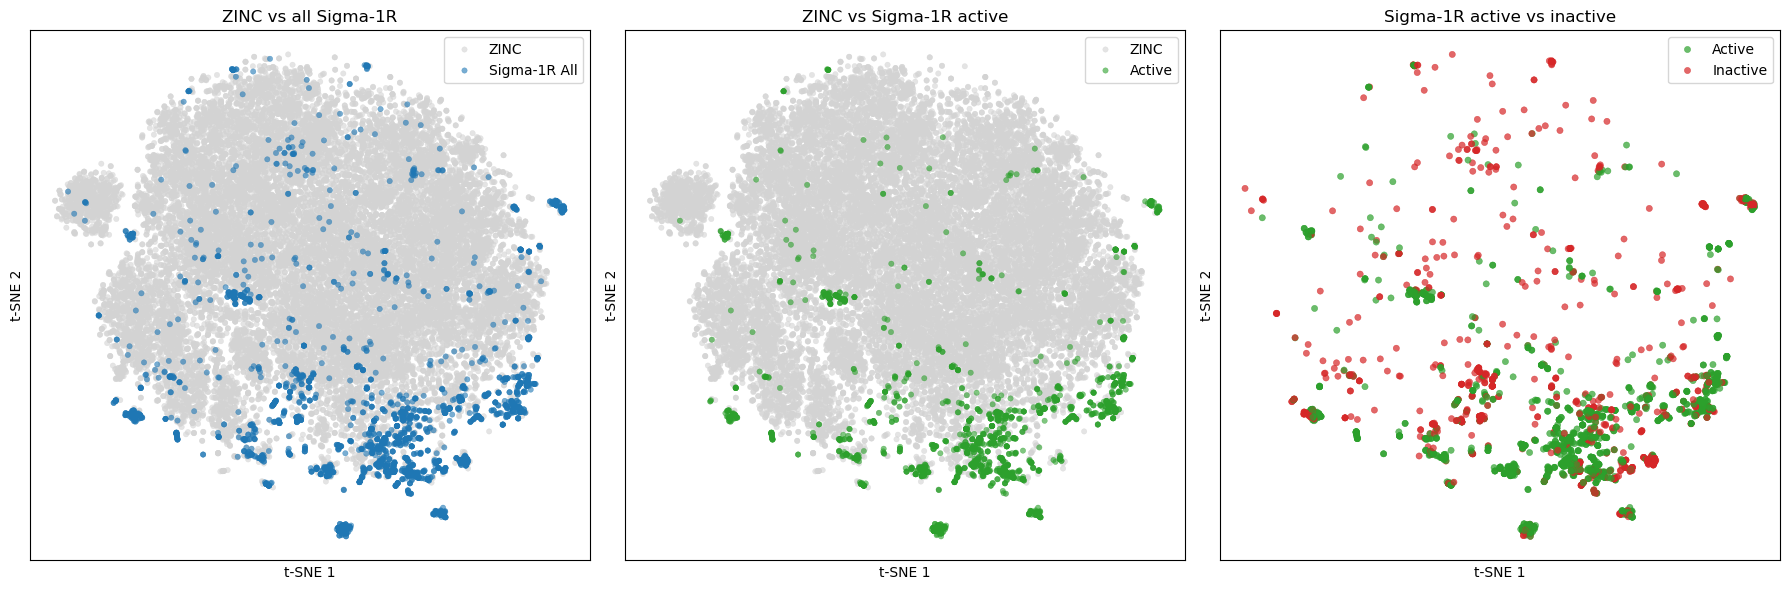

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

palette = {
    'ZINC': '#d3d3d3',
    'Sigma-1R All': '#1f77b4',
    'Active': '#2ca02c',
    'Inactive': '#d62728'
}

df_plot1 = df_embedding.copy()
df_plot1['category'] = df_plot1['category'].replace({
    'Active': 'Sigma-1R All',
    'Inactive': 'Sigma-1R All'
})

df_plot1 = df_plot1.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot1,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[0],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[0].set_title('ZINC vs all Sigma-1R')

df_plot2 = df_embedding[df_embedding['category'].isin(['ZINC', 'Active'])].copy()
df_plot2 = df_plot2.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot2,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[1],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[1].set_title('ZINC vs Sigma-1R active')

df_plot3 = df_embedding[df_embedding['category'].isin(['Active', 'Inactive'])]

sns.scatterplot(
    data=df_plot3,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[2],
    s=20,
    alpha=0.7,
    edgecolor=None
)
axes[2].set_title('Sigma-1R active vs inactive')

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

## UMAP

In [51]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.5)

umap_result = reducer.fit_transform(pca_result)

df_umap = pd.DataFrame({
    'x': umap_result[:, 0],
    'y': umap_result[:, 1],
    'category': all_labels
})

/home/Baaa/miniconda3/envs/cheminf/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


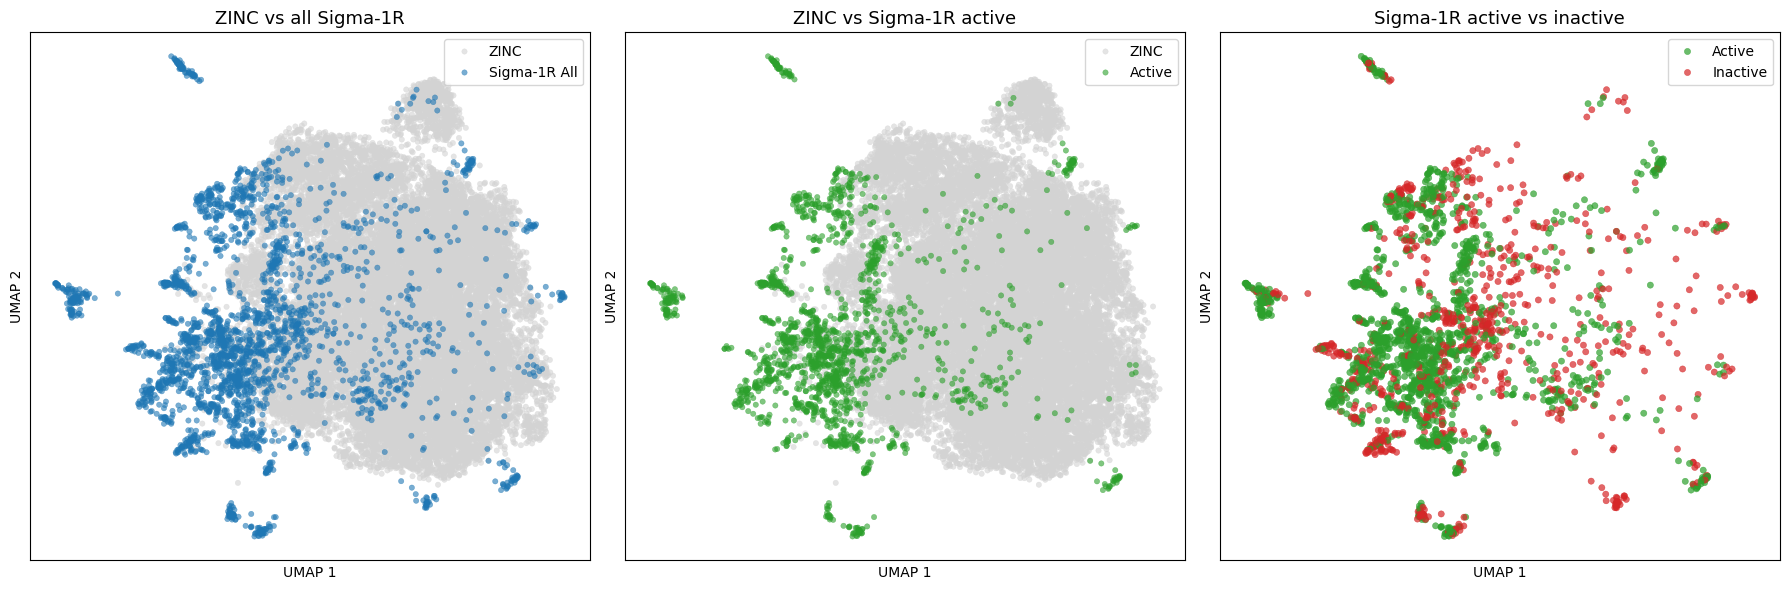

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_plot1 = df_umap.copy()
df_plot1['category'] = df_plot1['category'].replace({
    'Active': 'Sigma-1R All',
    'Inactive': 'Sigma-1R All'
})

df_plot1 = df_plot1.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot1,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[0],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[0].set_title('ZINC vs all Sigma-1R', fontsize=13)

df_plot2 = df_umap[df_umap['category'].isin(['ZINC', 'Active'])].copy()
df_plot2 = df_plot2.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot2,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[1],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[1].set_title('ZINC vs Sigma-1R active', fontsize=13)

df_plot3 = df_umap[df_umap['category'].isin(['Active', 'Inactive'])]

sns.scatterplot(
    data=df_plot3,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[2],
    s=20,
    alpha=0.7,
    edgecolor=None
)
axes[2].set_title('Sigma-1R active vs inactive', fontsize=13)

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

# ErG fingerprints

In [53]:
from rdkit.Chem.rdReducedGraphs import GetErGFingerprint

In [61]:
receptor_fps_erg = [GetErGFingerprint(m) for m in df_receptor['mol']]
zinc_fps_erg = [GetErGFingerprint(m) for m in df_zinc['mol']]

In [62]:
all_fps_erg = np.array(receptor_fps_erg + zinc_fps_erg)

In [63]:
pca = PCA(n_components=50, random_state=42)
pca_result_erg = pca.fit_transform(all_fps_erg)

## tSNE

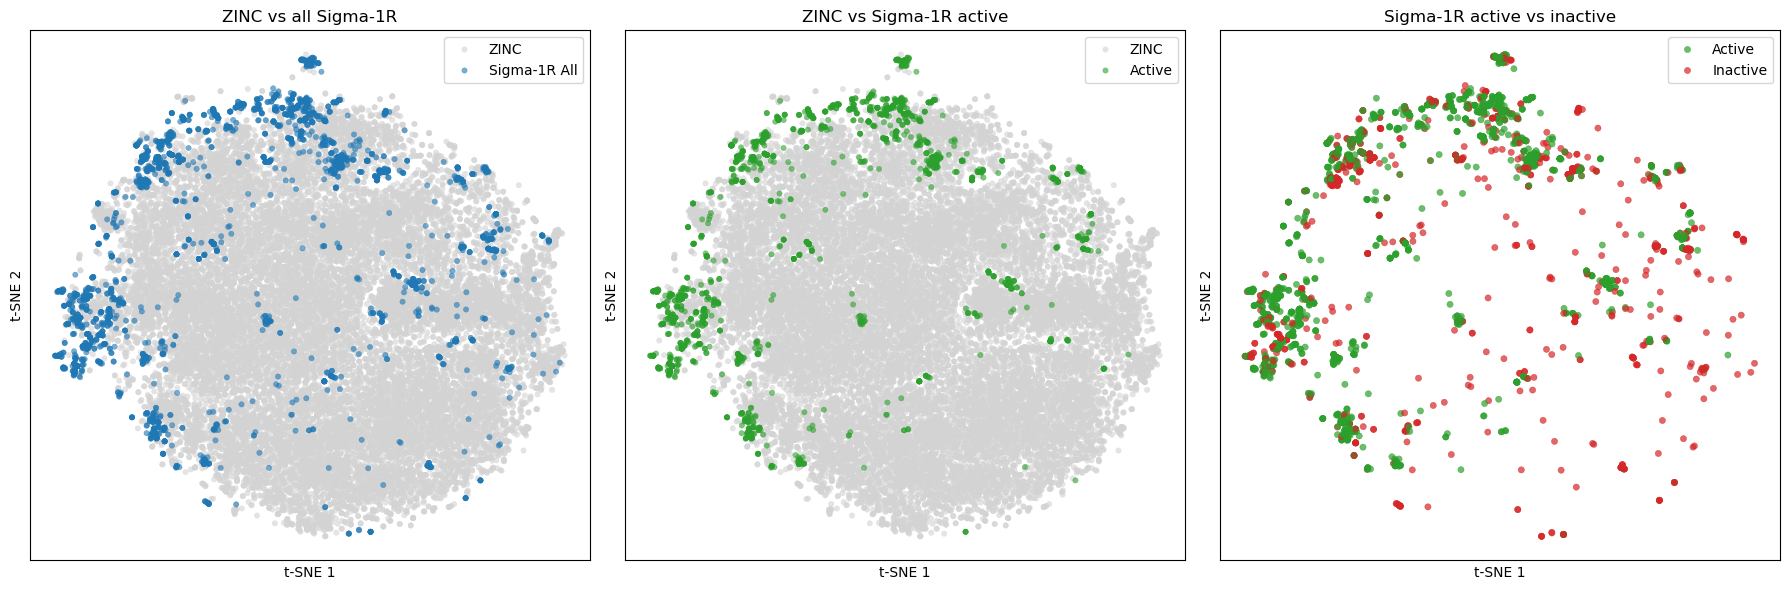

In [66]:
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=80)
tsne_result_erg = tsne.fit_transform(pca_result_erg)

df_embedding_erg = pd.DataFrame({
    'x': tsne_result_erg[:, 0],
    'y': tsne_result_erg[:, 1],
    'category': all_labels
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

palette = {
    'ZINC': '#d3d3d3',
    'Sigma-1R All': '#1f77b4',
    'Active': '#2ca02c',
    'Inactive': '#d62728'
}

df_plot1 = df_embedding_erg.copy()
df_plot1['category'] = df_plot1['category'].replace({
    'Active': 'Sigma-1R All',
    'Inactive': 'Sigma-1R All'
})

df_plot1 = df_plot1.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot1,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[0],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[0].set_title('ZINC vs all Sigma-1R')

df_plot2 = df_embedding_erg[df_embedding_erg['category'].isin(['ZINC', 'Active'])].copy()
df_plot2 = df_plot2.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot2,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[1],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[1].set_title('ZINC vs Sigma-1R active')

df_plot3 = df_embedding_erg[df_embedding_erg['category'].isin(['Active', 'Inactive'])]

sns.scatterplot(
    data=df_plot3,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[2],
    s=20,
    alpha=0.7,
    edgecolor=None
)
axes[2].set_title('Sigma-1R active vs inactive')

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

## UMAP

/home/Baaa/miniconda3/envs/cheminf/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


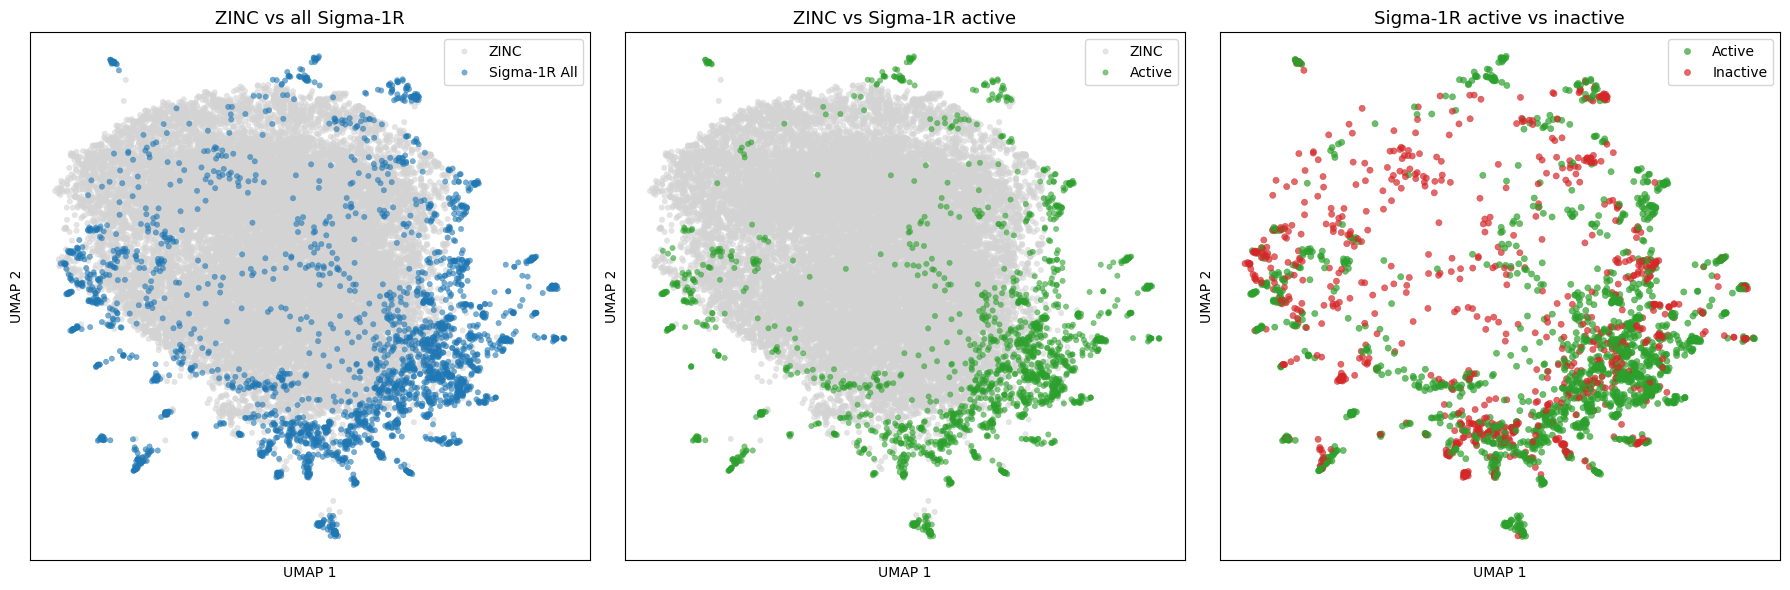

In [72]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.5)

umap_result = reducer.fit_transform(pca_result_erg)

df_umap = pd.DataFrame({
    'x': umap_result[:, 0],
    'y': umap_result[:, 1],
    'category': all_labels
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_plot1 = df_umap.copy()
df_plot1['category'] = df_plot1['category'].replace({
    'Active': 'Sigma-1R All',
    'Inactive': 'Sigma-1R All'
})

df_plot1 = df_plot1.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot1,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[0],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[0].set_title('ZINC vs all Sigma-1R', fontsize=13)

df_plot2 = df_umap[df_umap['category'].isin(['ZINC', 'Active'])].copy()
df_plot2 = df_plot2.sort_values('category', ascending=False)

sns.scatterplot(
    data=df_plot2,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[1],
    s=15,
    alpha=0.6,
    edgecolor=None
)
axes[1].set_title('ZINC vs Sigma-1R active', fontsize=13)

df_plot3 = df_umap[df_umap['category'].isin(['Active', 'Inactive'])]

sns.scatterplot(
    data=df_plot3,
    x='x',
    y='y',
    hue='category',
    palette=palette,
    ax=axes[2],
    s=20,
    alpha=0.7,
    edgecolor=None
)
axes[2].set_title('Sigma-1R active vs inactive', fontsize=13)

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='best')

plt.tight_layout()
plt.show()